In [1]:
from astroquery.gaia import Gaia
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from astrometry_equations import angular_distance
from astropy.io import fits


In [4]:
#plt.style.available
plt.style.use('default')
mpl.rcParams['axes.grid'] = True
mpl.rcParams['lines.linewidth'] = 1.5
mpl.rcParams['font.size'] = 11
mpl.rcParams['font.family'] = 'serif'

In [ ]:
# Histogram of Displacement
fig, ax = plt.subplots(1,1, figsize=(8,4))

mask = theta_as > 0
ax.hist(np.log10(theta_as[mask]), density=True, log=True, histtype='step', lw=4, label=r"M$_G$ < 12")

ax.set_xlabel(r"$^{10}$log Angular Displacement [arcseconds]")
ax.set_ylabel("Normalized Counts")
ax.set_title("Histogram Angular Displacement propagated over 24.75 years")

plt.legend()
#plt.savefig('../../figures/bprop_theta_gaia12',bbox_inches='tight', transparent=True)
plt.show()

In [ ]:
# Bugfixing, discretization/rouding errors going on in np.arccos


In [ ]:
username = 'rkievit'
Gaia.login(user=username)

# Study of Gaia DR3 M_G < 12 Selection

In [ ]:
job = Gaia.launch_job_async("SELECT gaia12.*, gaia.bp_rp\
                            FROM user_rkievit.gaia_sel12_prop as gaia12 \
                            JOIN gaiadr3.gaia_source_lite AS gaia USING (source_id)")

In [ ]:
r = job.get_results()

In [ ]:
plx_mask = ~r['parallax'].mask # Hotfix because we did not filter out the Gaia objects without plx/pm information
r.remove_rows(np.where(~plx_mask)[0])

In [ ]:
nu = np.sqrt((r['pmra']**2) + r['pmdec']**2)/1e3
theta = angular_distance(r['ra'], r['dec'], r['ra_prop'], r['dec_prop'], nu, unit='degrees', nu_thresh=1e10)
theta_as = 3600. * np.degrees(theta)

In [ ]:
print(np.sort(np.unique(theta, return_counts=True)))

In [ ]:
min_nu = 91321
sin = np.sin(r['dec'][min_nu])*np.sin(r['dec_prop'][min_nu])
print(sin)
cos = np.cos(r['dec'][min_nu])*np.cos(r['dec_prop'][min_nu])*np.cos(r['ra'][min_nu]-r['ra_prop'][min_nu])
print(cos)
print(f"{sin+cos:.60f}")

In [ ]:
# Histogram of Displacement
fig, ax = plt.subplots(1,1, figsize=(8,4))

mask = theta_as > 0
ax.hist(np.log10(theta_as[mask]), density=True, log=True, histtype='step', lw=4, label=r"M$_G$ < 12")

ax.set_xlabel(r"$^{10}$log Angular Displacement [arcseconds]")
ax.set_ylabel("Normalized Counts")
ax.set_title("Histogram Angular Displacement propagated over 24.75 years")

plt.legend()
plt.savefig('../../figures/bprop_theta_gaia12',bbox_inches='tight', transparent=True)
plt.show()

In [ ]:
# Density Distribution of Proper Motion vs. Displacement
fig, ax = plt.subplots(1,1, figsize=(8,8))

nu = np.sqrt((r['pmra']**2) + r['pmdec']**2)/1e3
ax.hexbin(np.log10(theta_as), np.log10(nu), bins='log', mincnt=1, cmap='jet', label=r"M$_G$ < 12") # Density distribution

ax.set_xlabel(r"$^{10}$log Angular Displacement [arcseconds]")
ax.set_ylabel(r"$^{10}$log Total Proper Motion [arcseconds/year]")
ax.set_title("Proper Motion versus Displacement propagated over 24.75 years")

plt.legend()
plt.savefig('../../figures/bprop_theta_nu_gaia12',bbox_inches='tight',transparent=True)
plt.show()

In [ ]:
# Distribution of Proper Motion vs. Displacement coded by Declination
fig, ax = plt.subplots(1,1, figsize=(9,8))

nu = np.sqrt((r['pmra']**2) + r['pmdec']**2)/1e3
nu_theta = ax.scatter(np.log10(theta_as), np.log10(nu), c=r['dec'], s=2, label=r"M$_G$ < 12", cmap='jet')
cb = plt.colorbar(nu_theta)
ax.axhline(y=-3, label=r"$\mu$-Cutoff Point (10$^{-3}$)")


cb.set_label("Declination (J2016.0) [Deg]")
ax.set_xlabel(r"$^{10}$log Angular Displacement [arcseconds]")
ax.set_ylabel(r"$^{10}$log Total Proper Motion [arcseconds/year]")
ax.set_title("Proper Motion versus Displacement propagated over 24.75 years")

plt.legend()
plt.savefig('../../figures/bprop_theta_nu_gaia12_dec',bbox_inches='tight',transparent=True)
plt.show()

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(9,8))

abs_mag = r['phot_g_mean_mag'] + 5.*(np.log10(r['parallax']/1e3) + 1.)

cmd = ax.scatter(r['bp_rp'], abs_mag, c=np.log10(theta_as), s=2, cmap='jet')
cb = plt.colorbar(cmd)

cb.set_label(r"$^{10}$ log Angular Displacement [arcseconds]")
ax.set_xlabel(r"Gaia B$_P$ - R$_P$ Colour")
ax.set_ylabel(r"Gaia Absolute M$_G$")
ax.set_title(r"Colour-Magnitude Diagram with $\theta$ Colour Coding")

ax.invert_yaxis()

big_xlim = ax.get_xlim()
big_ylim = ax.get_ylim()

plt.savefig('../../figures/bprop_cmd_gaia12',bbox_inches='tight',transparent=True)
#ax.hexbin(r_c['bp_rp'], abs_mag, bins='log', mincnt=1, label=r'M$_G$ < 12', cmap='jet')

# Gaia DR3 - Hipparcos2 Simple Crossmatch for M_G < 12

In [6]:
#job_xm = Gaia.launch_job_async("SELECT * \
#                               FROM user_rkievit.xm_hipp_gaia12_mid")
#r_xm = job_xm.get_results()
xm_tab = np.load("../results/conesearch_1as_gaia_sel12.npy")

In [7]:
gaia_id = xm_tab[:,1]#r_xm['source_id']
hipp_id = xm_tab[:,0]#r_xm['hip']
sep = xm_tab[:,2]#r_xm['dist_arcsec']

In [8]:
print(f"The cross-match between Hipp2 and Gaia DR3 resulted in {len(gaia_id)} matches.")
u_g, c_g = np.unique(gaia_id, return_counts=True)#u are all unique instances, c is the amount of counts for each unique item in u
print(f"Duplicate Gaia objects: {len(u_g[c_g>1])}")

u_h, c_h =  np.unique(hipp_id, return_counts=True)
print(f"Duplicate Hipp objects: {len(u_h[c_h>1])}")
print(np.max(c_h[c_h>1]))

The cross-match between Hipp2 and Gaia DR3 resulted in 117423 matches.
Duplicate Gaia objects: 0
Duplicate Hipp objects: 731
2


In [27]:
print(u_g[c_g>1])
#print(xm_tab[hipp_id == 3])
#print(xm_tab)
print(u_g)

[-2.3872257e+18]
[-2.38722570e+18  4.00000000e+00  7.00000000e+00 ...  2.34187167e+18
  2.73832753e+18  2.88174298e+18]


C:\Users\Rens\AppData\Local\Temp/ipykernel_1956/807528274.py:3: RuntimeWarning: invalid value encountered in log10
  ax.hist(np.log10(sep), log=True,histtype='step',density=True,lw=4)


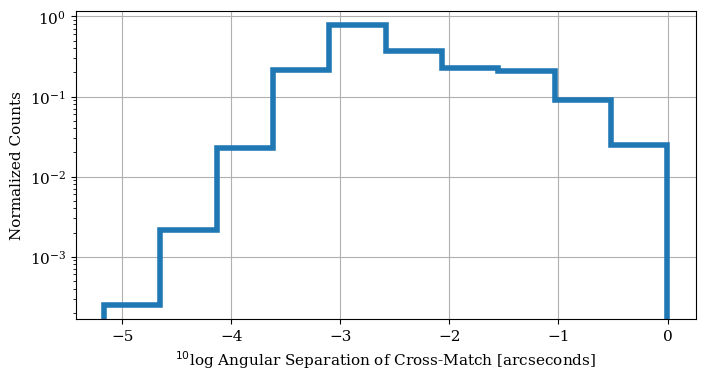

In [20]:
fig, ax = plt.subplots(1,1,figsize=(8,4))

ax.hist(np.log10(sep), log=True,histtype='step',density=True,lw=4)

ax.set_xlabel(r"$^{10}$log Angular Separation of Cross-Match [arcseconds]")
ax.set_ylabel("Normalized Counts")

plt.savefig('../../figures/simple_xm_1as_10k', bbox_inches='tight')#, transparent=True)
plt.show()

In [ ]:
query_xm = 'SELECT ra, dec, plx, pm_ra, pm_de, hp_mag ' \
           'FROM public.hipparcos_newreduction AS hipp' \
           'JOIN user_rkievit.xm_hipp_gaia12_mid AS xm ' \
           '    ON hipp.hip = xm.hip'
job_xm = Gaia.launch_job_async(query=query_xm, name='in_xm_stars')

In [5]:
fits_gaia = fits.open('../data/gaia_stars_sel12_noerr.fits')

In [ ]:
#print(fits_gaia[1].header)
#new_table = fits_gaia[1].data[:5]
fits_gaia[1].data = fits_gaia[1].data[:5]
#print(new_table[0].header)


In [ ]:
print(fits_gaia[1].data['ra_prop'])

In [30]:
#print(fits_gaia[1].header)
#new_table = fits_gaia[1].data[:5]
fits_gaia[1].data = fits_gaia[1].data[:5]
#print(new_table[0].header)


In [31]:
print(fits_gaia[1].data['ra_prop'])

[193.50817847 332.05907779 206.88432674  95.74037353  10.12662946]
